# MPC with Single Step AE-NARX

In [1]:
""" # Cell 1: Imports and Model Loading
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import casadi as ca
import do_mpc
import torch, numpy as np, yaml
from common.mpc_common import NARXWindowManager, load_scaler, scale, unscale, export_narx_ae_compact

MODEL_DIR = '../training/Models/version_12' #AE-NARX model
narx_model = torch.load(f'{MODEL_DIR}/narx_model_full.pt', map_location='cpu',
                        weights_only=False)
narx_model.eval() # set to eval mode for inference

feat_scaler = load_scaler(f'{MODEL_DIR}/feature_scaler.yml')
label_scaler = load_scaler(f'{MODEL_DIR}/label_scaler.yml')

with open(f'{MODEL_DIR}/model_metadata.yml') as f:
    _mm = yaml.safe_load(f)
metadata = _mm['dataset_metadata']

# transition_fn: (1,34)[z:25|u:8|tvp:1] → (1,25)  z_next  (decode+roll+encode inside PyTorch)
# pred_fn:       (1,25)[z]               → (1,26)  y_pred
transition_fn, pred_fn = export_narx_ae_compact(narx_model) """

# Cell 1: Imports and Model Loading
import os
os.environ['OMP_NUM_THREADS'] = '1'   # MUST be set before torch/l4casadi load
os.environ['MKL_NUM_THREADS'] = '1'

import sys
sys.path.insert(0, os.path.abspath('../..'))

import casadi as ca
import do_mpc
import torch, numpy as np, yaml

torch.set_num_threads(1)              # single intra-op thread -> stops CasADi clock glitch
try:
    torch.set_num_interop_threads(1)  # must be before any parallel work (fresh kernel)
except RuntimeError:
    pass                              # already initialised; ignore

from common.mpc_common import NARXWindowManager, load_scaler, scale, unscale, export_narx_ae_compact

MODEL_DIR = '../training/Models/version_12' #AE-NARX model
narx_model = torch.load(f'{MODEL_DIR}/narx_model_full.pt', map_location='cpu',
                        weights_only=False)
narx_model.eval()

feat_scaler = load_scaler(f'{MODEL_DIR}/feature_scaler.yml')
label_scaler = load_scaler(f'{MODEL_DIR}/label_scaler.yml')

with open(f'{MODEL_DIR}/model_metadata.yml') as f:
    _mm = yaml.safe_load(f)
metadata = _mm['dataset_metadata']

# transition_fn: (1,34)[z:25|u:8|tvp:1] -> (1,25)  z_next
# pred_fn:       (1,25)[z]               -> (1,26)  y_pred
transition_fn, pred_fn = export_narx_ae_compact(narx_model)

print('torch threads:', torch.get_num_threads(), '| interop:', torch.get_num_interop_threads())

/home/harshit/.venvs/thesis-env/lib/python3.12/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/harshit/.venvs/thesis-env/lib/python3.12/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


torch threads: 1 | interop: 1


In [2]:
# Cell 2: do-mpc discrete model state

model = do_mpc.model.Model(model_type='discrete', symvar_type='MX')

# State --
z = model.set_variable('_x','z', shape=(25,1))

# Control inputs --
u = model.set_variable('_u','T_setpoint_sc',shape=(8,1))

# Time-varying parameter --
tvp = model.set_variable('_tvp','flow_inlet_sc',shape=(1,1))

# Predicted outputs (z → 26 outputs) --
y_pred = pred_fn(z.T).T   # (26, 1)

# State transition: decode+roll+encode in one PyTorch forward pass --
z_u_tvp = ca.vertcat(z, u, tvp).T   # (1, 34)
z_next  = transition_fn(z_u_tvp).T  # (25, 1)
model.set_rhs('z', z_next)

# Auxiliary expressions --
model.set_expression('T_reactor_pred',   y_pred[0:9])
model.set_expression('heating_power_pred', y_pred[17:25])
model.set_expression('T_reactor_max',    y_pred[25])

model.setup()


/usr/lib/python3.12/ast.py:407: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


In [3]:
# Cell 3: MPC Controller

N_HORIZON = 25   # MPC Horizon
Q_track  = 1.0   # K^-2 per zone: each K^2 of tracking error → 1 unit cost
R_energy = 1e-6  # W^-2 per zone: each W^2 of heating power → 1e-6 unit cost
                 # ratio Q/R ~ 1e6 K^2/W^2 → at 5 K error and 500 W per zone,
                 # tracking term ≈ 25, energy term ≈ 0.25 (100:1 favour tracking)
R_du     = 2.0   # Rate penalty on scaled T_setpoint (scaled units)
T_sp     = 330.0 # Setpoint temperature (K)

n_react = 9.0 # No of reactor zones
n_heat =  8.0 # No of heating zones

# Unscaling constants — bring predictions back to physical units inside CasADi.
# Cost is evaluated in K^2/zone and W^2/zone so Q/R weights are physically
# interpretable and independent of the label normalisation.
_lmean_t = label_scaler['mean'][0:9].reshape(9, 1)   # K
_lstd_t  = label_scaler['std'][0:9].reshape(9, 1)    # K
_lmean_h = label_scaler['mean'][17:25].reshape(8, 1)  # W
_lstd_h  = label_scaler['std'][17:25].reshape(8, 1)   # W

mpc = do_mpc.controller.MPC(model)
mpc.settings.n_horizon = N_HORIZON
mpc.settings.t_step = 15.0

# IPOPT: L-BFGS Hessian approximation. The l4casadi transition only exposes
# first-order derivatives (its reverse-mode adj1 codegen is buggy for the GELU
# encoder/decoder composite), so we must NOT request an exact Hessian.
mpc.settings.nlpsol_opts = {
    'ipopt.hessian_approximation': 'limited-memory',
    'ipopt.tol': 1e-4,
    'ipopt.acceptable_tol': 1e-3,
    'ipopt.acceptable_iter': 5,
    'ipopt.max_iter': 100,
    'ipopt.print_level': 0,
    'print_time': False,
    'record_time': False,   # disable CasADi eval timing -> avoids WSL2 'time>=0' crash
}

# Objective — physical-space cost (K² and W² per zone) --
# Unscale model predictions to physical units
T_reactor_phys = (model.aux['T_reactor_pred']    * ca.DM(_lstd_t) + ca.DM(_lmean_t))  # (9,1) K
heating_phys   = (model.aux['heating_power_pred'] * ca.DM(_lstd_h) + ca.DM(_lmean_h)) # (8,1) W

# MSE formulation: normalise by number of zones → weights are zone-count invariant
lterm = (Q_track  * ca.sumsqr(T_reactor_phys - T_sp) / n_react +  # mean K^2 tracking error
         R_energy * ca.sumsqr(heating_phys) / n_heat)   # mean W^2 energy cost
mterm = lterm  # no terminal cost (yet)
mpc.set_objective(lterm=lterm, mterm=mterm)

# Control-rate penalty (acts on scaled setpoint deltas)
mpc.set_rterm(T_setpoint_sc=R_du)

# Input constraints (bounds in scaled feature space for T_setpoint) --
T_min_sc = (292.0 - feat_scaler['mean'][2628:2636]) / feat_scaler['std'][2628:2636]
T_max_sc = (365.0 - feat_scaler['mean'][2628:2636]) / feat_scaler['std'][2628:2636]
mpc.bounds['lower', '_u', 'T_setpoint_sc'] = T_min_sc.reshape(8,1)
mpc.bounds['upper', '_u', 'T_setpoint_sc'] = T_max_sc.reshape(8,1)

# Safety constraint: T_reactor_max < 380 K --
T_safe_sc = (380.0 - label_scaler['mean'][25]) / label_scaler['std'][25]
mpc.set_nl_cons('T_max_safe', model.aux['T_reactor_max'], ub=T_safe_sc)

# TVP Function --
flow_traj_sc = np.zeros((N_HORIZON + 1))

tvp_template = mpc.get_tvp_template()
def tvp_fun(t_now):
    k = int(np.asarray(t_now).item() / 15.0)
    for i in range(N_HORIZON + 1):
        tvp_template['_tvp', i, 'flow_inlet_sc'] = float(flow_traj_sc[min(k + i, N_HORIZON)])
    return tvp_template
mpc.set_tvp_fun(tvp_fun)

mpc.setup()

In [4]:
# Cell 4 : CL simulation

import h5py, os, sys, time

# Load initial window from dataset --
# NOTE: the dataset stores PHYSICAL units (temps ~330 K); the AE was trained on
# SCALED features, so we MUST apply feat_scaler before encoding. Feeding raw
# physical data gives a latent of magnitude ~2000 and an unsolvable NLP.
DATASET_PATH = '../../Data_Sampling/datasets/21_05_2026/narx/thermal_narx_dataset_3.h5'
with h5py.File(DATASET_PATH, 'r') as f:
    x0_window_phys = f['narx_state_features'][-1, :].astype(np.float64)

x0_window_sc = (x0_window_phys - feat_scaler['mean']) / feat_scaler['std']  # -> scaled

win_mgr = NARXWindowManager(metadata)
win_mgr.window = x0_window_sc.copy()

# Encode initial window (scaled) --
x0_t = torch.tensor(x0_window_sc.astype(np.float32)).unsqueeze(0)
with torch.no_grad():
    z0 = narx_model.encoder(x0_t).squeeze(0).numpy()
x0 = z0.reshape(-1, 1)
print(f'z0 latent: min {z0.min():.2f}  max {z0.max():.2f}  std {z0.std():.2f}  (sane if std ~O(1-10))')

mpc.x0 = x0
mpc.set_initial_guess()

# CL simulation -- DIAGNOSTIC: short run with per-step wall-clock timing.
# Raise N_SIM back to 100 once each make_step is confirmed fast (<~few s).
N_SIM = 100
x_log, u_log, y_log = [x0.copy()], [], []
x_k = x0.copy()

for k in range(N_SIM):
    _t0 = time.time()
    u_k = mpc.make_step(x_k)
    _dt = time.time() - _t0
    print(f'[step {k:3d}] make_step: {_dt:7.2f} s', flush=True)
    mpc.set_initial_guess()   # reset multipliers to avoid stale-warmstart NaN crash

    u_scaled = u_k.flatten()
    flow_scaled = float(flow_traj_sc[min(k, N_HORIZON)])

    # NARX Fwd pass --
    x_win = win_mgr.get_window().astype(np.float32)
    with torch.no_grad():
        y_pred_sc = narx_model.predict(torch.tensor(x_win).unsqueeze(0)).squeeze(0).numpy()

    win_mgr.update(y_pred_sc, u_scaled, flow_scaled, metadata['labels'])

    x_next = win_mgr.get_window().astype(np.float32)
    with torch.no_grad():
        z_next = narx_model.encoder(torch.tensor(x_next).unsqueeze(0)).squeeze(0).numpy()
    x_k = z_next.reshape(-1, 1)

    x_log.append(x_k.copy())
    u_log.append(u_k.copy())
    y_log.append(y_pred_sc.copy())

print(f'Simulation complete: {N_SIM} steps')


z0 latent: min -8.94  max 15.11  std 5.22  (sane if std ~O(1-10))

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

[step   0] make_step:   40.25 s
[step   1] make_step:   38.46 s
[step   2] make_step:   37.48 s
[step   3] make_step:   33.91 s
[step   4] make_step:   35.27 s
[step   5] make_step:   36.66 s
[step   6] make_step:   36.86 s
[step   7] make_step:   35.27 s
[step   8] make_step:   34.81 s
[step   9] make_step:   35.06 s
[step  10] make_step:   36.95 s
[step  11] make_step:   34.77 s
[step  12] make_step:   33.33 s
[step  13] make_step:   34.58 s
[step  14] make_step:   34.39 s
[step  15] make_step:   30.44 s
[step  16] make_step:   32.69 s
[st

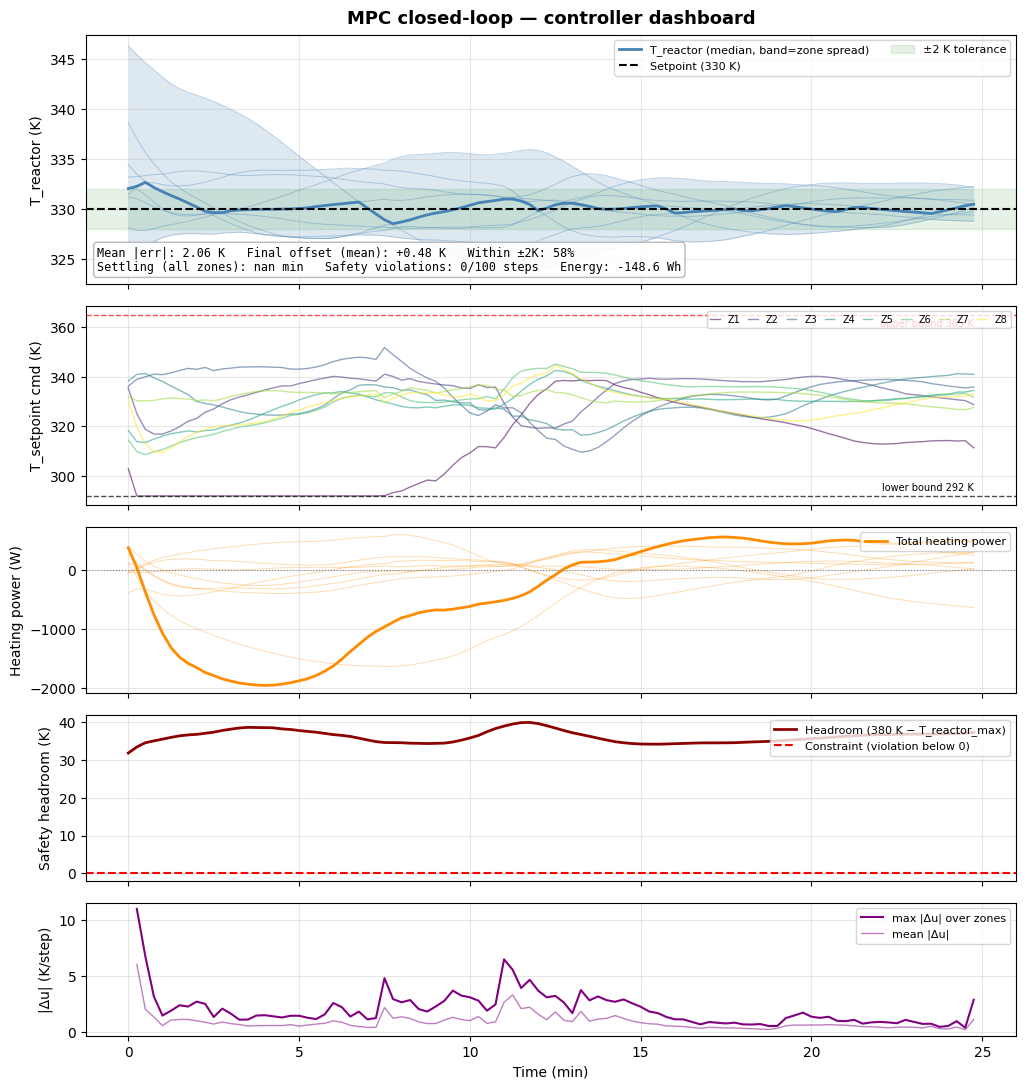

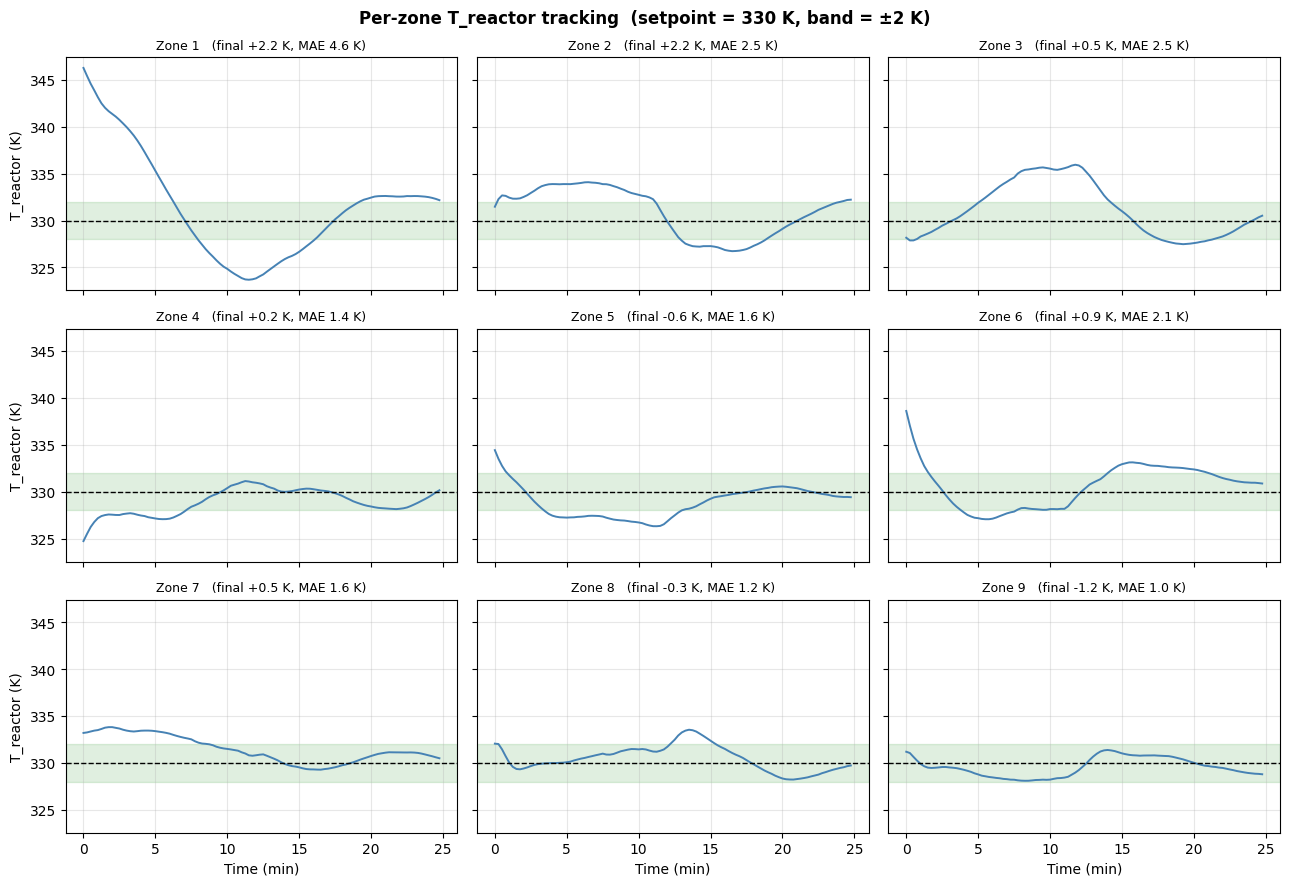

Per-zone reactor tracking (K):
  Zone 1:  MAE  4.62   final offset  +2.17
  Zone 2:  MAE  2.50   final offset  +2.22
  Zone 3:  MAE  2.53   final offset  +0.51
  Zone 4:  MAE  1.39   final offset  +0.15
  Zone 5:  MAE  1.60   final offset  -0.58
  Zone 6:  MAE  2.13   final offset  +0.87
  Zone 7:  MAE  1.64   final offset  +0.49
  Zone 8:  MAE  1.17   final offset  -0.28
  Zone 9:  MAE  0.97   final offset  -1.21

Overall mean |err|: 2.059 K  (0.62%)
Within ±2 K:    58.2% of (step,zone) samples
Max T_reactor_max: 348.17 K  (bound 380 K, min headroom 31.8 K)
Safety violations: 0 / 100 steps
Total heating energy: -148.6 Wh


In [5]:
# Cell 5 - Closed-loop diagnostics dashboard
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# -- Unscale logged data --
u_arr = np.array([u.flatten() for u in u_log])
y_arr = np.array(y_log)
t     = np.arange(len(u_arr)) * 15.0 / 60.0

T_set_mean = feat_scaler['mean'][2628:2636]
T_set_std  = feat_scaler['std'][2628:2636]
T_set_phys = u_arr * T_set_std + T_set_mean

T_react_phys = y_arr[:, 0:9]  * label_scaler['std'][0:9]  + label_scaler['mean'][0:9]
T_therm_phys = y_arr[:, 9:17] * label_scaler['std'][9:17] + label_scaler['mean'][9:17]
heat_phys    = y_arr[:, 17:25]* label_scaler['std'][17:25]+ label_scaler['mean'][17:25]
T_react_max  = y_arr[:, 25]   * label_scaler['std'][25]   + label_scaler['mean'][25]

tracking_err = T_react_phys - T_sp
TOL = 2.0

mean_abs_err = np.abs(tracking_err).mean(axis=0)
overall_mae  = mean_abs_err.mean()
final_err    = tracking_err[-1]
pct_in_tol   = 100.0 * (np.abs(tracking_err) <= TOL).mean()
n_violation  = int((T_react_max > 380.0).sum())
total_energy = heat_phys.sum() * 15.0 / 3600.0
settled = np.all(np.abs(tracking_err) <= TOL, axis=1)
if settled.any():
    idx = np.where(settled)[0]
    runs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
    tail = next((r for r in runs if r[-1] == len(t) - 1), None)
    settle_t = t[tail[0]] if tail is not None else np.nan
else:
    settle_t = np.nan

metrics_txt = (
    f"Mean |err|: {overall_mae:.2f} K   "
    f"Final offset (mean): {final_err.mean():+.2f} K   "
    f"Within ±{TOL:.0f}K: {pct_in_tol:.0f}%\n"
    f"Settling (all zones): {settle_t:.1f} min   "
    f"Safety violations: {n_violation}/{len(t)} steps   "
    f"Energy: {total_energy:.1f} Wh"
)

def envelope(ax, t, arr, color, label, lw=2.0):
    lo, hi, mid = arr.min(axis=1), arr.max(axis=1), np.median(arr, axis=1)
    ax.fill_between(t, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.plot(t, mid, color=color, lw=lw, label=label)
    return mid

fig = plt.figure(figsize=(12, 13))
gs  = gridspec.GridSpec(5, 1, height_ratios=[3, 2.4, 2, 2, 1.6], hspace=0.12)
axT  = fig.add_subplot(gs[0])
axU  = fig.add_subplot(gs[1], sharex=axT)
axP  = fig.add_subplot(gs[2], sharex=axT)
axS  = fig.add_subplot(gs[3], sharex=axT)
axD  = fig.add_subplot(gs[4], sharex=axT)

for i in range(9):
    axT.plot(t, T_react_phys[:, i], color='steelblue', lw=0.7, alpha=0.35)
envelope(axT, t, T_react_phys, 'steelblue', 'T_reactor (median, band=zone spread)')
axT.axhline(T_sp, color='black', ls='--', lw=1.5, label=f'Setpoint ({T_sp:.0f} K)')
axT.axhspan(T_sp - TOL, T_sp + TOL, color='green', alpha=0.10, label=f'±{TOL:.0f} K tolerance')
axT.set_ylabel('T_reactor (K)')
axT.set_title('MPC closed-loop — controller dashboard', fontsize=13, fontweight='bold', pad=8)
axT.legend(loc='upper right', fontsize=8, ncol=2)
axT.grid(True, alpha=0.3)
axT.text(0.012, 0.04, metrics_txt, transform=axT.transAxes, fontsize=8.5,
         va='bottom', ha='left', family='monospace',
         bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.9))

for i in range(8):
    axU.plot(t, T_set_phys[:, i], lw=1.0, alpha=0.55,
             color=plt.cm.viridis(i / 7), label=f'Z{i+1}')
axU.axhline(292.0, color='black', ls='--', lw=1.0, alpha=0.7)
axU.axhline(365.0, color='red',   ls='--', lw=1.0, alpha=0.7)
axU.text(t[-1], 293.5, 'lower bound 292 K', fontsize=7, ha='right', va='bottom', color='black')
axU.text(t[-1], 363.5, 'upper bound 365 K', fontsize=7, ha='right', va='top', color='red')
axU.set_ylabel('T_setpoint cmd (K)')
axU.legend(loc='upper right', fontsize=7, ncol=8, columnspacing=0.8, handlelength=1.0)
axU.grid(True, alpha=0.3)

heat_total = heat_phys.sum(axis=1)
for i in range(8):
    axP.plot(t, heat_phys[:, i], color='darkorange', lw=0.7, alpha=0.30)
axP.plot(t, heat_total, color='darkorange', lw=2.0, label='Total heating power')
axP.axhline(0, color='grey', lw=0.8, ls=':')
axP.set_ylabel('Heating power (W)')
axP.legend(loc='upper right', fontsize=8)
axP.grid(True, alpha=0.3)

headroom = 380.0 - T_react_max
axS.plot(t, headroom, color='darkred', lw=2.0, label='Headroom (380 K − T_reactor_max)')
axS.axhline(0.0, color='red', ls='--', lw=1.5, label='Constraint (violation below 0)')
axS.fill_between(t, headroom, 0.0, where=(headroom < 0), color='red', alpha=0.35)
axS.set_ylabel('Safety headroom (K)')
axS.legend(loc='upper right', fontsize=8)
axS.grid(True, alpha=0.3)

du = np.abs(np.diff(T_set_phys, axis=0))
axD.plot(t[1:], du.max(axis=1), color='purple', lw=1.5, label='max |Δu| over zones')
axD.plot(t[1:], du.mean(axis=1), color='purple', lw=1.0, alpha=0.5, label='mean |Δu|')
axD.set_ylabel('|Δu| (K/step)')
axD.set_xlabel('Time (min)')
axD.legend(loc='upper right', fontsize=8)
axD.grid(True, alpha=0.3)

for ax in (axT, axU, axP, axS):
    plt.setp(ax.get_xticklabels(), visible=False)

plt.savefig('mpc_ssa_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    ax.plot(t, T_react_phys[:, i], color='steelblue', lw=1.4)
    ax.axhline(T_sp, color='black', ls='--', lw=1.0)
    ax.axhspan(T_sp - TOL, T_sp + TOL, color='green', alpha=0.12)
    ax.set_title(f'Zone {i+1}   (final {final_err[i]:+.1f} K, MAE {mean_abs_err[i]:.1f} K)', fontsize=9)
    ax.grid(True, alpha=0.3)
    if i >= 6: ax.set_xlabel('Time (min)')
    if i % 3 == 0: ax.set_ylabel('T_reactor (K)')
fig.suptitle(f'Per-zone T_reactor tracking  (setpoint = {T_sp:.0f} K, band = ±{TOL:.0f} K)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mpc_ssa_tracking_grid.png', dpi=150)
plt.show()

print('Per-zone reactor tracking (K):')
for i in range(9):
    print(f'  Zone {i+1}:  MAE {mean_abs_err[i]:5.2f}   final offset {final_err[i]:+6.2f}')
print(f'\nOverall mean |err|: {overall_mae:.3f} K  ({overall_mae/T_sp*100:.2f}%)')
print(f'Within ±{TOL:.0f} K:    {pct_in_tol:.1f}% of (step,zone) samples')
print(f'Max T_reactor_max: {T_react_max.max():.2f} K  (bound 380 K, min headroom {headroom.min():.1f} K)')
print(f'Safety violations: {n_violation} / {len(t)} steps')
print(f'Total heating energy: {total_energy:.1f} Wh')
